In [ ]:
from preprocessing.file_conversion import file_conversion
import numpy as np 

path = "/Users/reymendoza/Desktop/sleep_files"
X, y, groups = file_conversion(path)
#np.savez_compressed("sleep_dataset_16.npz", X=X, y=y, groups=groups)

Processing: sub-001_ses-001_task-sleep_acq-PSG_eeg.set
Reading /Users/reymendoza/Desktop/sleep_files/sub-001/ses-001/sub-001_ses-001_task-sleep_acq-PSG_eeg.fdt
Reading 0 ... 14255559  =      0.000 ... 28511.118 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

  Feature matrix shape: (942, 19)
Processing: sub-002_ses-001_task-sleep_acq-PSG_eeg.set
Reading /Users/reymendoza/Desktop/sleep_files/sub-002/ses-001/sub-002_ses-001_task-sleep_acq-PSG_eeg.fdt
Reading 0 ... 15034689 

In [11]:
X[13638]

array([-6.0420194e+00, -6.6997242e+00, -6.9197679e+00, -6.9061699e+00,
       -7.4321890e+00,  6.5364116e-01,  1.4375836e-01,  8.6613931e-02,
        8.9368828e-02,  2.6616979e-02,  6.5770417e-01,  8.7774807e-01,
        2.2004175e-01,  8.6414987e-01, -1.3601825e-02,  1.8151003e-04,
        4.5416510e-01,  3.5539551e+00,  1.1597182e+00], dtype=float32)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",   # or "f1_macro"
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y_3class, groups=groups)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/reymendoza/Developer/Sleep-Stage-Classification/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

n_splits = 5
cv = StratifiedGroupKFold(n_splits, shuffle=True, random_state=42)
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
scaler = StandardScaler()
all_results = []
all_y_true = []
all_y_pred = []
all_y_proba = []
cms = []
y_3class = np.where(y == 1, 1, np.where(y == 2, 2, 3))
class_labels = [1, 2, 3]

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y_3class, groups=groups)):

    print(f"Fold {fold}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_3class[train_idx], y_3class[test_idx]
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    fold_results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_weighted": roc_auc_score(
            y_test, y_proba, multi_class="ovr", average="weighted"
        ),
        "cm": confusion_matrix(y_test, y_pred),
    }
    
    all_results.append(fold_results)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_proba.append(y_proba)
    cms.append(confusion_matrix(y_test, y_pred, labels=class_labels))
    
summary = {
    metric: np.mean([fold[metric] for fold in all_results])
    for metric in all_results[0]
}

print("\nMean CV results:")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

Fold 0
Fold 1
Fold 2
Fold 3
Fold 4

Mean CV results:
accuracy: 0.6808
balanced_accuracy: 0.5032
precision_macro: 0.5699
recall_macro: 0.5032
f1_macro: 0.4983
precision_weighted: 0.6695
recall_weighted: 0.6808
f1_weighted: 0.6544
roc_auc_ovr_weighted: 0.7383
cm: 303.0889


In [96]:
class_counts = pd.Series(y_3class).value_counts().sort_index()
print("\nClass counts:")
print(class_counts)

class_props = pd.Series(y_3class).value_counts(normalize=True).sort_index()
print("\nClass proportions:")
print(class_props.round(3))


Class counts:
1    2015
2    9341
3    2283
Name: count, dtype: int64

Class proportions:
1    0.148
2    0.685
3    0.167
Name: proportion, dtype: float64


In [97]:
# class labels in sorted order
class_labels = np.unique(y_3class)
print("\nClassification report:")
print(classification_report(
    all_y_true,
    all_y_pred,
    labels=class_labels,
    digits=3,
    zero_division=0
))


Classification report:
              precision    recall  f1-score   support

           1      0.408     0.478     0.440      2015
           2      0.753     0.845     0.796      9341
           3      0.510     0.177     0.262      2283

    accuracy                          0.679     13639
   macro avg      0.557     0.500     0.500     13639
weighted avg      0.661     0.679     0.654     13639



Row-normalized confusion matrix:
[[0.47841191 0.49826303 0.02332506]
 [0.11872391 0.84487742 0.03639867]
 [0.12702584 0.69645204 0.17652212]]


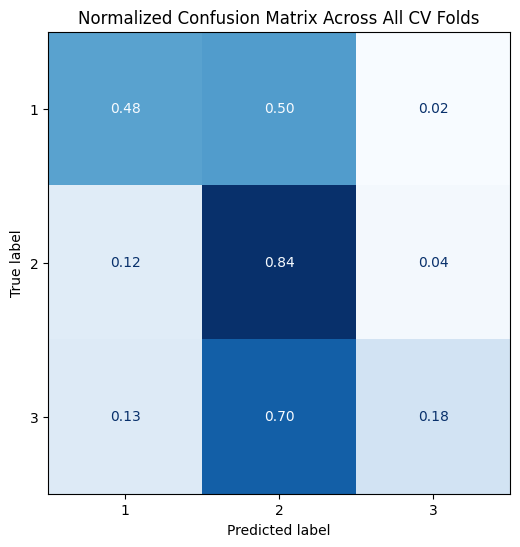

In [98]:
# sum confusion matrices across folds
cm_sum = np.sum(cms, axis=0)

cm_norm = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)

print("Row-normalized confusion matrix:")
print(cm_norm)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Normalized Confusion Matrix Across All CV Folds")
plt.show()

In [99]:
feature_names = [
    "delta_abs_bandpower",
    "theta_abs_bandpower",
    "alpha_abs_bandpower",
    "beta_abs_bandpower",
    "gamma_abs_bandpower",
    "delta_rel_bandpower",
    "theta_rel_bandpower",
    "alpha_rel_bandpower",
    "beta_rel_bandpower",
    "gamma_rel_bandpower",
    "delta_theta_ratio",
    "delta_alpha_ratio",
    "theta_alpha_ratio",
    "delta_beta_ratio",
    "alpha_beta_ratio",
    "hjorth_activity",
    "hjorth_mobility",
    "hjorth_complexity",
    "spectral_entropy",
]
rf_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y_3class)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 features:")
print(importance_df.head(20))


Top 20 features:
                feature  importance
4   gamma_abs_bandpower    0.107172
3    beta_abs_bandpower    0.077528
9   gamma_rel_bandpower    0.065784
18     spectral_entropy    0.064313
6   theta_rel_bandpower    0.063433
2   alpha_abs_bandpower    0.063382
1   theta_abs_bandpower    0.060503
0   delta_abs_bandpower    0.060453
16      hjorth_mobility    0.050076
10    delta_theta_ratio    0.047812
17    hjorth_complexity    0.046869
14     alpha_beta_ratio    0.045391
12    theta_alpha_ratio    0.044991
8    beta_rel_bandpower    0.041659
13     delta_beta_ratio    0.040410
11    delta_alpha_ratio    0.039942
7   alpha_rel_bandpower    0.038680
5   delta_rel_bandpower    0.036344
15      hjorth_activity    0.005257


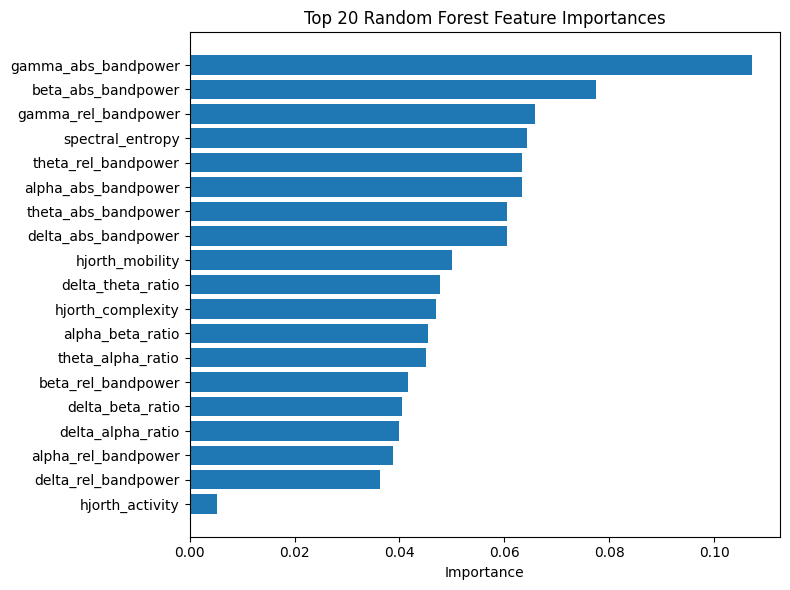

In [100]:
top_n = 20
top_feats = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()